# U-Net Instance Segmentation — Full Pipeline
**Preprocessing → Training (From Scratch + Fine-tuning) → Evaluation**

- Annotation parsing (bbox + segmentation polygons → binary masks)
- Top-5 class selection, filtering, stratified train/val/test splits
- U-Net trained from scratch (random init)
- U-Net fine-tuned (ImageNet-pretrained ResNet-34 encoder via `segmentation_models_pytorch`)
- Resumable training: checkpoint auto-saved every epoch, auto-loaded on re-run
- Post-processing: connected components → bounding boxes → majority-vote class labels
- Evaluation: per-class mIoU, Dice, COCO-style mAP@[0.5:0.95], ROC/AUC
- **TPU-compatible**: wraps model in `torch_xla` when a TPU device is detected

---
**Hardware targets**: Kaggle T4 GPU (8 GB) · Kaggle TPU v5e-8 · local RTX 4060 8 GB

---
# PART 0 — Imports & Configuration

In [ ]:
# Install required dependencies
!pip install -q segmentation-models-pytorch
!pip install -q tensorflow-cpu


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# -------------------- Imports --------------------
import os
import json
import random
import glob
import math
import warnings

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from scipy import ndimage as ndi

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T


# segmentation_models_pytorch gives us pretrained encoders for free
try:
    import segmentation_models_pytorch as smp
    SMP_AVAILABLE = True
except ImportError:
    SMP_AVAILABLE = False
    print("[WARN] segmentation_models_pytorch not found. "
          "Fine-tuning with pretrained encoder is disabled. "
          "Install with: pip install segmentation-models-pytorch")


# -------------------- Device setup --------------------
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl

    TPU_AVAILABLE = True
    DEVICE = torch_xla.device()
    TPU_VERSION = "v5e"

    print(f"TPU v5e-8 detected: {DEVICE}")
    print(f"torch_xla version : {torch_xla.__version__}")

except ImportError:
    TPU_AVAILABLE = False
    TPU_VERSION = None
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"Device: {DEVICE}")


# -------------------- Environment --------------------
ON_KAGGLE = os.path.exists("/kaggle")
NUM_WORKERS = 0 if (ON_KAGGLE or TPU_AVAILABLE) else 2


# -------------------- Reproducibility --------------------
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if not TPU_AVAILABLE and torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


warnings.filterwarnings("ignore", category=UserWarning)

print("Imports OK")

/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


E0000 00:00:1774728038.222042      74 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238


TPU v5e-8 detected: xla:0
torch_xla version : 2.8.0
Imports OK


In [ ]:
# -------------------- Configuration --------------------

# Dataset paths
BASE_PATH            = "/kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2"
TRAIN_IMAGE_DIR      = f"{BASE_PATH}/train/image"
TRAIN_ANNOTATION_DIR = f"{BASE_PATH}/train/annos"
VAL_IMAGE_DIR        = f"{BASE_PATH}/validation/image"
VAL_ANNOTATION_DIR   = f"{BASE_PATH}/validation/annos"

# Output directory
WORK_DIR = "/kaggle/working"

# Subset sizes
SUBSET_SIZE_SCRATCH  = 40000
SUBSET_SIZE_FINETUNE = 15000

# Filtering
MIN_BBOX_AREA      = 5000
MIN_POLYGON_POINTS = 3
TEST_SPLIT         = 0.10

# Image size
IMG_SIZE = 256

# Training parameters
BATCH_SIZE   = 32
ACCUM_STEPS  = 2
NUM_EPOCHS   = 15
LR_SCRATCH   = 1e-3
LR_FINETUNE  = 1e-4
WEIGHT_DECAY = 1e-4

# Validation
VAL_MAP_SAMPLES = 300

# Classes
NUM_CLASSES = 6

# Category names
CATEGORY_NAMES = {
    1: "short_sleeve_top",
    2: "long_sleeve_top",
    3: "short_sleeve_outwear",
    4: "long_sleeve_outwear",
    5: "vest",
    6: "sling",
    7: "shorts",
    8: "trousers",
    9: "skirt",
    10: "short_sleeve_dress",
    11: "long_sleeve_dress",
    12: "vest_dress",
    13: "sling_dress",
}

# Checkpoints
SCRATCH_CKPT_PATH  = f"{WORK_DIR}/unet_scratch_ckpt.pth"
SCRATCH_BEST_PATH  = f"{WORK_DIR}/unet_scratch_best.pth"
FINETUNE_CKPT_PATH = f"{WORK_DIR}/unet_finetune_ckpt.pth"
FINETUNE_BEST_PATH = f"{WORK_DIR}/unet_finetune_best.pth"


print("Config loaded.")
print(f"Scratch subset : {SUBSET_SIZE_SCRATCH:,}")
print(f"Finetune subset: {SUBSET_SIZE_FINETUNE:,}")
print(f"IMG_SIZE: {IMG_SIZE}  BATCH: {BATCH_SIZE}  ACCUM: {ACCUM_STEPS}  EPOCHS: {NUM_EPOCHS}")

Config loaded.
Scratch subset : 40,000
Finetune subset: 15,000
IMG_SIZE: 256  BATCH: 32  ACCUM: 2  EPOCHS: 15


---
# PART 1 — Preprocessing

## 1. Parse Annotations

In [ ]:
def _process_annotation_file(args):
    file, annotation_dir, image_dir = args

    json_path  = os.path.join(annotation_dir, file)
    image_name = file.replace(".json", ".jpg")
    image_path = os.path.join(image_dir, image_name)

    if not os.path.exists(image_path):
        return None

    with open(json_path) as f:
        data = json.load(f)

    items = []
    for key, value in data.items():
        if not key.startswith("item"):
            continue

        cat_id = value.get("category_id")
        bbox   = value.get("bounding_box")
        segs   = value.get("segmentation")

        if cat_id is None or bbox is None or segs is None:
            continue

        valid_segs = [
            s for s in segs
            if isinstance(s, list) and len(s) >= MIN_POLYGON_POINTS * 2
        ]
        if not valid_segs:
            continue

        x1, y1, x2, y2 = bbox
        if (x2 - x1) * (y2 - y1) < MIN_BBOX_AREA:
            continue

        items.append({
            "category_id": cat_id,
            "bbox": bbox,
            "segmentation": valid_segs
        })

    if not items:
        return None

    return {
        "image_name": image_name,
        "image_path": image_path,
        "items": items
    }


def parse_annotations(annotation_dir, image_dir, workers=8):
    files = [f for f in os.listdir(annotation_dir) if f.endswith(".json")]
    args  = [(f, annotation_dir, image_dir) for f in files]

    with ThreadPoolExecutor(max_workers=workers) as ex:
        results = list(ex.map(_process_annotation_file, args))

    return [r for r in results if r is not None]


print("Parsing TRAIN annotations…")
train_records = parse_annotations(TRAIN_ANNOTATION_DIR, TRAIN_IMAGE_DIR)
print(f"  Train: {len(train_records):,} records")

print("Parsing VAL annotations…")
val_records = parse_annotations(VAL_ANNOTATION_DIR, VAL_IMAGE_DIR)
print(f"  Val  : {len(val_records):,} records")

Parsing TRAIN annotations…


  Train: 191,750 records
Parsing VAL annotations…


  Val  : 32,125 records


## 2. Top-5 Categories

In [ ]:
# Category distribution
category_counter = Counter()

for record in train_records:
    for item in record["items"]:
        category_counter[item["category_id"]] += 1


print("Category distribution (training):")
for cat_id, count in category_counter.most_common():
    print(f"  [{cat_id:2d}] {CATEGORY_NAMES[cat_id]:<25} : {count:,}")


# Top-5 categories
top5_ids = [cat_id for cat_id, _ in category_counter.most_common(5)]

cat_to_label = {
    cat_id: idx + 1
    for idx, cat_id in enumerate(top5_ids)
}

label_to_name = {
    0: "background",
    **{v: CATEGORY_NAMES[k] for k, v in cat_to_label.items()}
}


print(f"\nTop-5 IDs   : {top5_ids}")
print(f"Top-5 names : {[CATEGORY_NAMES[c] for c in top5_ids]}")
print(f"Label map   : {cat_to_label}")

## 3. Filter & Stratified Subset

In [ ]:
def filter_to_top5(records, top5_ids):
    filtered = []
    for record in records:
        valid = [it for it in record["items"] if it["category_id"] in top5_ids]
        if valid:
            filtered.append({**record, "items": valid})
    return filtered


def records_to_df(records, top5_ids):
    rows = []
    for rec in records:
        label = [0] * len(top5_ids)
        for item in rec["items"]:
            label[top5_ids.index(item["category_id"])] = 1
        rows.append([rec["image_name"]] + label)

    return pd.DataFrame(rows, columns=["image_name"] + [f"class_{c}" for c in top5_ids])


def make_subset(filtered_records, top5_ids, subset_size):
    df = records_to_df(filtered_records, top5_ids)
    lc = df.columns[1:]

    df["primary_class"] = df[lc].idxmax(axis=1)

    if subset_size and subset_size < len(df):
        df_sub, _ = train_test_split(
            df,
            train_size=subset_size,
            stratify=df["primary_class"],
            random_state=42
        )
    else:
        df_sub = df.copy()

    name_map = {r["image_name"]: r for r in filtered_records}
    return [name_map[n] for n in df_sub["image_name"] if n in name_map]


train_filtered = filter_to_top5(train_records, top5_ids)
val_filtered   = filter_to_top5(val_records,   top5_ids)


scratch_all  = make_subset(train_filtered, top5_ids, SUBSET_SIZE_SCRATCH)
finetune_all = make_subset(train_filtered, top5_ids, SUBSET_SIZE_FINETUNE)


def split_train_test(records, test_frac=TEST_SPLIT):
    df = records_to_df(records, top5_ids)
    lc = df.columns[1:]

    df["primary_class"] = df[lc].idxmax(axis=1)

    tr, te = train_test_split(
        df,
        test_size=test_frac,
        stratify=df["primary_class"],
        random_state=42
    )

    name_map = {r["image_name"]: r for r in records}

    return (
        [name_map[n] for n in tr["image_name"] if n in name_map],
        [name_map[n] for n in te["image_name"] if n in name_map]
    )


scratch_train,  scratch_test  = split_train_test(scratch_all)
finetune_train, finetune_test = split_train_test(finetune_all)


random.shuffle(val_filtered)
val_records_capped = val_filtered[:3000]


print(f"Scratch  — train: {len(scratch_train):,}  test: {len(scratch_test):,}")
print(f"Finetune — train: {len(finetune_train):,}  test: {len(finetune_test):,}")
print(f"Val (capped)    : {len(val_records_capped):,}")

Scratch  — train: 36,000  test: 4,000
Finetune — train: 13,500  test: 1,500
Val (capped)    : 3,000


## 4. Dataset & DataLoader

In [ ]:
# -------------------- Image size cache --------------------
_dim_cache = {}


def get_image_size(path):
    if path not in _dim_cache:
        with Image.open(path) as img:
            _dim_cache[path] = img.size
    return _dim_cache[path]


# -------------------- Mask generation --------------------
def build_semantic_mask(record, img_w, img_h, cat_to_label):
    mask = np.zeros((img_h, img_w), dtype=np.uint8)

    for item in record["items"]:
        if item["category_id"] not in cat_to_label:
            continue

        label = cat_to_label[item["category_id"]]

        for polygon in item["segmentation"]:
            if len(polygon) < 6:
                continue

            pts = np.array(polygon, dtype=np.float32).reshape(-1, 2)
            pts = np.clip(pts, [0, 0], [img_w - 1, img_h - 1]).astype(np.int32)

            cv2.fillPoly(mask, [pts], color=int(label))

    return mask


# -------------------- Transforms --------------------
def get_train_transforms(img_size):
    return T.Compose([
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225],
        ),
    ])


def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225],
        ),
    ])


# -------------------- Dataset --------------------
class DeepFashionSegDataset(Dataset):

    def __init__(self, records, cat_to_label, img_size, augment=False):
        self.records = records
        self.cat_to_label = cat_to_label
        self.img_size = img_size
        self.augment = augment
        self.image_tfm = get_train_transforms(img_size) if augment else get_val_transforms()

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        path = rec["image_path"]

        img_pil = Image.open(path).convert("RGB")
        img_w, img_h = img_pil.size

        mask_np = build_semantic_mask(rec, img_w, img_h, self.cat_to_label)

        img_pil = img_pil.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )

        if self.augment and random.random() > 0.5:
            img_pil = TF.hflip(img_pil)
            mask_pil = TF.hflip(mask_pil)

        img_tensor = self.image_tfm(img_pil)
        mask_tensor = torch.from_numpy(np.array(mask_pil)).long()

        return img_tensor, mask_tensor


# -------------------- DataLoaders --------------------
def make_loader(records, cat_to_label, img_size, batch_size,
                augment=False, shuffle=False):

    ds = DeepFashionSegDataset(records, cat_to_label, img_size, augment=augment)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=not TPU_AVAILABLE,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=shuffle,
    )


scratch_train_loader  = make_loader(scratch_train,      cat_to_label, IMG_SIZE, BATCH_SIZE, augment=True,  shuffle=True)
scratch_test_loader   = make_loader(scratch_test,       cat_to_label, IMG_SIZE, BATCH_SIZE)
finetune_train_loader = make_loader(finetune_train,     cat_to_label, IMG_SIZE, BATCH_SIZE, augment=True,  shuffle=True)
finetune_test_loader  = make_loader(finetune_test,      cat_to_label, IMG_SIZE, BATCH_SIZE)
val_loader            = make_loader(val_records_capped, cat_to_label, IMG_SIZE, BATCH_SIZE)


print("DataLoaders ready.")
print(f"  Scratch train batches : {len(scratch_train_loader)}")
print(f"  Finetune train batches: {len(finetune_train_loader)}")

DataLoaders ready.
  Scratch train batches : 1125
  Finetune train batches: 421


## 5. Class Weights

In [ ]:
def compute_class_weights(records, top5_ids, cat_to_label):
    inst = Counter()

    for rec in records:
        for item in rec["items"]:
            inst[item["category_id"]] += 1

    total = sum(inst[c] for c in top5_ids)
    nc = len(top5_ids)

    weights = [0.1]

    for cat_id in top5_ids:
        weights.append(total / (nc * inst[cat_id] + 1e-6))

    return torch.tensor(weights, dtype=torch.float32)


scratch_class_weights  = compute_class_weights(scratch_train,  top5_ids, cat_to_label)
finetune_class_weights = compute_class_weights(finetune_train, top5_ids, cat_to_label)


print(f"Scratch  class weights : {scratch_class_weights.tolist()}")
print(f"Finetune class weights : {finetune_class_weights.tolist()}")

Scratch  class weights : [0.10000000149011612, 0.6433824896812439, 0.8304884433746338, 1.2642943859100342, 1.2735258340835571, 1.502793788909912]
Finetune class weights : [0.10000000149011612, 0.6418874859809875, 0.8329534530639648, 1.2645747661590576, 1.2799643278121948, 1.4936612844467163]


---
# PART 2 — Model Architecture

In [ ]:
# -------------------- Scratch U-Net --------------------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetEncoder(nn.Module):
    def __init__(self, in_channels, features):
        super().__init__()
        self.convs = nn.ModuleList()
        self.pools = nn.ModuleList()

        ch = in_channels
        for f in features:
            self.convs.append(DoubleConv(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

    def forward(self, x):
        skips = []
        for conv, pool in zip(self.convs, self.pools):
            x = conv(x)
            skips.append(x)
            x = pool(x)
        return x, skips


class UNetDecoder(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.upconvs = nn.ModuleList()
        self.convs = nn.ModuleList()

        for i in range(len(features) - 1):
            self.upconvs.append(
                nn.ConvTranspose2d(features[i], features[i+1], kernel_size=2, stride=2)
            )
            self.convs.append(DoubleConv(features[i+1] * 2, features[i+1]))

    def forward(self, x, skips):
        for up, conv, skip in zip(self.upconvs, self.convs, reversed(skips)):
            x = up(x)

            if x.shape != skip.shape:
                x = TF.resize(x, skip.shape[2:])

            x = torch.cat([skip, x], dim=1)
            x = conv(x)

        return x


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=6, features=(64, 128, 256, 512)):
        super().__init__()

        self.encoder = UNetEncoder(in_channels, features)
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        dec_features = [features[-1] * 2] + list(reversed(features))
        self.decoder = UNetDecoder(dec_features)

        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        x, skips = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        return self.head(x)


# -------------------- Sanity check --------------------
_dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
_model = UNet(num_classes=NUM_CLASSES)

_out = _model(_dummy)
print(f"UNet output shape: {_out.shape}")

n_params = sum(p.numel() for p in _model.parameters())
print(f"Scratch U-Net parameters: {n_params:,}")

del _dummy, _model, _out

UNet output shape: torch.Size([1, 6, 256, 256])
Scratch U-Net parameters: 31,037,958


In [ ]:
def build_pretrained_unet(num_classes, encoder_name="resnet34"):
    if not SMP_AVAILABLE:
        print("[WARN] smp not available — using scratch U-Net as fine-tune base.")
        return UNet(num_classes=num_classes)

    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes,
        activation=None,
    )

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Pretrained U-Net ({encoder_name}) parameters: {n_params:,}")

    return model


# Test instantiation
_m = build_pretrained_unet(NUM_CLASSES)

_d = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
_o = _m(_d)

print(f"Pretrained U-Net output shape: {_o.shape}")

del _m, _d, _o

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Pretrained U-Net (resnet34) parameters: 24,437,094


Pretrained U-Net output shape: torch.Size([1, 6, 256, 256])


## Loss Function

In [ ]:
class CombinedSegLoss(nn.Module):
    def __init__(self, class_weights, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dw = dice_weight
        self.smooth = smooth

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)

        probs = torch.softmax(logits, dim=1)
        n_cls = logits.shape[1]

        dice = 0.0
        n_fg = 0

        for c in range(1, n_cls):
            p = probs[:, c]
            t = (targets == c).float()

            inter = (p * t).sum()
            union = p.sum() + t.sum()

            dice += 1 - (2 * inter + self.smooth) / (union + self.smooth)
            n_fg += 1

        dice /= max(n_fg, 1)

        return self.dw * dice + (1 - self.dw) * ce_loss

---
# PART 3 — Training Utilities

In [12]:
# -------------------------------------------------------
# Per-epoch validation metric (fast)
# -------------------------------------------------------
def compute_miou(model, loader, num_classes, device, max_samples=VAL_MAP_SAMPLES):
    """
    Compute mean IoU over the first `max_samples` images in the loader.

    We only count classes that actually appear in the ground truth to
    avoid inflating mIoU by classes absent from the sampled batch.
    """
    model.eval()
    intersection = torch.zeros(num_classes)
    union        = torch.zeros(num_classes)
    seen = 0

    with torch.no_grad():
        for imgs, masks in loader:
            if seen >= max_samples:
                break
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs).argmax(dim=1)   # (B, H, W)
            if TPU_AVAILABLE:
                xm.mark_step()   # flush XLA graph each batch to prevent graph accumulation OOM
            for c in range(num_classes):
                pred_c = (preds == c)
                mask_c = (masks == c)
                intersection[c] += (pred_c & mask_c).sum().item()
                union[c]        += (pred_c | mask_c).sum().item()
            seen += imgs.shape[0]

    ious = []
    for c in range(1, num_classes):   # skip background
        if union[c] > 0:
            ious.append((intersection[c] / union[c]).item())
    return float(np.mean(ious)) if ious else 0.0


# -------------------------------------------------------
# Checkpoint helpers
# -------------------------------------------------------
def save_checkpoint(state, path):
    """
    Save training state dict so we can resume from any epoch.
    On TPU v5e, xm.save() is required — it transfers XLA tensors to CPU
    before pickling. torch.save() on a live XLA tensor saves garbage.
    """
    if TPU_AVAILABLE:
        xm.save(state, path)   # TPU v5e-safe: moves tensors off XLA device first
    else:
        torch.save(state, path)


def load_checkpoint(path, model, optimizer, scheduler):
    """
    Load a saved checkpoint into model / optimiser / scheduler.
    Always load to CPU first, then move model to the correct device.
    This is the safe pattern for both GPU and TPU v5e (XLA device).
    Returns (start_epoch, best_miou, train_losses).
    """
    ckpt = torch.load(path, map_location="cpu", weights_only=False)  # always load to CPU first
    model.load_state_dict(ckpt["model"])
    model.to(DEVICE)                              # then move to XLA / CUDA / CPU
    if TPU_AVAILABLE:
        xm.mark_step()                           # sync XLA graph after weight transfer
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    return ckpt["epoch"] + 1, ckpt["best_miou"], ckpt.get("train_losses", [])


# -------------------------------------------------------
# Training loop (shared by scratch and fine-tune)
# -------------------------------------------------------
def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,
                num_epochs, device,
                ckpt_path, best_path,
                label=""):
    """
    Full training loop with:
    - Gradient accumulation (ACCUM_STEPS)
    - TPU v5e step: optimizer.step() + xm.mark_step() (xm.optimizer_step deprecated on v5e)
    - Per-epoch val mIoU on a random 300-image sample
    - Automatic checkpoint save / resume
    - Best model saved separately

    Returns a list of per-epoch average training losses.
    """
    model.to(device)

    # Auto-resume if a checkpoint already exists
    start_epoch, best_miou, train_losses = 0, 0.0, []
    if os.path.exists(ckpt_path):
        print(f"[{label}] Resuming from checkpoint: {ckpt_path}")
        start_epoch, best_miou, train_losses = load_checkpoint(
            ckpt_path, model, optimizer, scheduler)
        print(f"  Resumed at epoch {start_epoch}, best mIoU so far: {best_miou:.4f}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        optimizer.zero_grad()
        running_loss = 0.0
        n_batches    = 0

        # TPU parallel loader: keeps the data-pipeline and TPU compute in sync
        if TPU_AVAILABLE:
            loader_iter = pl.MpDeviceLoader(train_loader, device)
        else:
            loader_iter = train_loader

        for batch_idx, (imgs, masks) in enumerate(loader_iter):
            imgs  = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)           # forward pass
            loss   = criterion(logits, masks)

            # Scale loss so accumulated gradients match a single large-batch gradient
            (loss / ACCUM_STEPS).backward()

            running_loss += loss.item()
            n_batches    += 1

            if (batch_idx + 1) % ACCUM_STEPS == 0:
                optimizer.step()
                if TPU_AVAILABLE:
                    xm.mark_step()   # flush XLA graph — required on TPU v5e after every step
                                     # (replaces deprecated xm.optimizer_step on v5e/torch_xla 2.x)
                optimizer.zero_grad()

        # Flush any remaining gradient accumulation at epoch end
        if n_batches % ACCUM_STEPS != 0:
            optimizer.step()
            if TPU_AVAILABLE:
                xm.mark_step()
            optimizer.zero_grad()

        scheduler.step()

        avg_loss = running_loss / max(n_batches, 1)
        train_losses.append(avg_loss)

        # Fast per-epoch mIoU on a sample of the val set
        val_miou = compute_miou(model, val_loader, NUM_CLASSES, device)

        print(f"[{label}] Epoch {epoch+1:2d}/{num_epochs}  "
              f"loss={avg_loss:.4f}  val_mIoU={val_miou:.4f}")

        # Save best weights
        if val_miou > best_miou:
            best_miou = val_miou
            # xm.save moves XLA tensors to CPU before pickling (required on TPU v5e)
            if TPU_AVAILABLE:
                xm.save(model.state_dict(), best_path)
            else:
                torch.save(model.state_dict(), best_path)

        # Save full resumable checkpoint
        save_checkpoint({
            "epoch"       : epoch,
            "model"       : model.state_dict(),
            "optimizer"   : optimizer.state_dict(),
            "scheduler"   : scheduler.state_dict(),
            "best_miou"   : best_miou,
            "train_losses": train_losses,
        }, ckpt_path)

    print(f"[{label}] Training complete.  Best val mIoU: {best_miou:.4f}")
    return train_losses

---
# PART A — Train from Scratch
U-Net with randomly initialised weights — baseline.

In [ ]:
# -------------------- Validation (mIoU) --------------------
def compute_miou(model, loader, num_classes, device, max_samples=VAL_MAP_SAMPLES):
    model.eval()

    intersection = torch.zeros(num_classes)
    union = torch.zeros(num_classes)
    seen = 0

    with torch.no_grad():
        for imgs, masks in loader:
            if seen >= max_samples:
                break

            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs).argmax(dim=1)

            if TPU_AVAILABLE:
                xm.mark_step()

            for c in range(num_classes):
                pred_c = (preds == c)
                mask_c = (masks == c)

                intersection[c] += (pred_c & mask_c).sum().item()
                union[c] += (pred_c | mask_c).sum().item()

            seen += imgs.shape[0]

    ious = []
    for c in range(1, num_classes):
        if union[c] > 0:
            ious.append((intersection[c] / union[c]).item())

    return float(np.mean(ious)) if ious else 0.0


# -------------------- Checkpoints --------------------
def save_checkpoint(state, path):
    if TPU_AVAILABLE:
        xm.save(state, path)
    else:
        torch.save(state, path)


def load_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)

    model.load_state_dict(ckpt["model"])
    model.to(DEVICE)

    if TPU_AVAILABLE:
        xm.mark_step()

    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])

    return ckpt["epoch"] + 1, ckpt["best_miou"], ckpt.get("train_losses", [])


# -------------------- Training loop --------------------
def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,
                num_epochs, device,
                ckpt_path, best_path,
                label=""):

    model.to(device)

    start_epoch, best_miou, train_losses = 0, 0.0, []

    if os.path.exists(ckpt_path):
        print(f"[{label}] Resuming from checkpoint: {ckpt_path}")
        start_epoch, best_miou, train_losses = load_checkpoint(
            ckpt_path, model, optimizer, scheduler
        )
        print(f"  Resumed at epoch {start_epoch}, best mIoU so far: {best_miou:.4f}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        optimizer.zero_grad()

        running_loss = 0.0
        n_batches = 0

        if TPU_AVAILABLE:
            loader_iter = pl.MpDeviceLoader(train_loader, device)
        else:
            loader_iter = train_loader

        for batch_idx, (imgs, masks) in enumerate(loader_iter):
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            loss = criterion(logits, masks)

            (loss / ACCUM_STEPS).backward()

            running_loss += loss.item()
            n_batches += 1

            if (batch_idx + 1) % ACCUM_STEPS == 0:
                optimizer.step()

                if TPU_AVAILABLE:
                    xm.mark_step()

                optimizer.zero_grad()

        if n_batches % ACCUM_STEPS != 0:
            optimizer.step()

            if TPU_AVAILABLE:
                xm.mark_step()

            optimizer.zero_grad()

        scheduler.step()

        avg_loss = running_loss / max(n_batches, 1)
        train_losses.append(avg_loss)

        val_miou = compute_miou(model, val_loader, NUM_CLASSES, device)

        print(f"[{label}] Epoch {epoch+1:2d}/{num_epochs}  "
              f"loss={avg_loss:.4f}  val_mIoU={val_miou:.4f}")

        if val_miou > best_miou:
            best_miou = val_miou

            if TPU_AVAILABLE:
                xm.save(model.state_dict(), best_path)
            else:
                torch.save(model.state_dict(), best_path)

        save_checkpoint({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "best_miou": best_miou,
            "train_losses": train_losses,
        }, ckpt_path)

    print(f"[{label}] Training complete.  Best val mIoU: {best_miou:.4f}")

    return train_losses

Scratch U-Net — 31,037,958 parameters
Run next cell to train (or resume from checkpoint if it exists).


In [ ]:
scratch_train_losses = train_model(
    model=model_scratch,
    train_loader=scratch_train_loader,
    val_loader=val_loader,
    criterion=criterion_scratch,
    optimizer=optimizer_scratch,
    scheduler=scheduler_scratch,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    ckpt_path=SCRATCH_CKPT_PATH,
    best_path=SCRATCH_BEST_PATH,
    label="Scratch",
)

/tmp/ipykernel_74/1359446855.py:127: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()   # flush XLA graph — required on TPU v5e after every step


/tmp/ipykernel_74/1359446855.py:135: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_74/1359446855.py:24: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()   # flush XLA graph each batch to prevent graph accumulation OOM


[Scratch] Epoch  1/15  loss=1.2098  val_mIoU=0.1495


[Scratch] Epoch  2/15  loss=1.0695  val_mIoU=0.1795


...

[Scratch] Epoch 12/15  loss=0.5326  val_mIoU=0.4602


[Scratch] Epoch 13/15  loss=0.5090  val_mIoU=0.4898


[Scratch] Epoch 14/15  loss=0.4948  val_mIoU=0.4728


[Scratch] Epoch 15/15  loss=0.4861  val_mIoU=0.4762


[Scratch] Training complete.  Best val mIoU: 0.4898


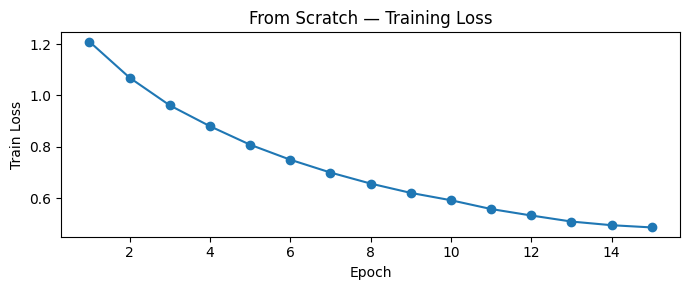

Saved loss curve.


In [15]:
# ---- Loss curve ----
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(scratch_train_losses) + 1), scratch_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("From Scratch — Training Loss")
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/unet_scratch_loss.png", dpi=120)
plt.show()
print("Saved loss curve.")

---
# PART B — Fine-tuning
U-Net with ImageNet-pretrained ResNet-34 encoder (all layers trainable, low LR).

In [ ]:
# Build pretrained model
model_ft = build_pretrained_unet(num_classes=NUM_CLASSES).to(DEVICE)

criterion_ft = CombinedSegLoss(
    class_weights=finetune_class_weights.to(DEVICE),
    dice_weight=0.5,
)

optimizer_ft = optim.AdamW(
    model_ft.parameters(),
    lr=LR_FINETUNE,
    weight_decay=WEIGHT_DECAY,
)

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=NUM_EPOCHS,
    eta_min=1e-7,
)

n_params = sum(p.numel() for p in model_ft.parameters())
print(f"Fine-tune U-Net — {n_params:,} parameters")
print("Run next cell to train (or resume from checkpoint if it exists).")

Pretrained U-Net (resnet34) parameters: 24,437,094
Fine-tune U-Net — 24,437,094 parameters
Run next cell to train (or resume from checkpoint if it exists).


In [17]:
finetune_train_losses = train_model(
    model        = model_ft,
    train_loader = finetune_train_loader,
    val_loader   = val_loader,
    criterion    = criterion_ft,
    optimizer    = optimizer_ft,
    scheduler    = scheduler_ft,
    num_epochs   = NUM_EPOCHS,
    device       = DEVICE,
    ckpt_path    = FINETUNE_CKPT_PATH,
    best_path    = FINETUNE_BEST_PATH,
    label        = "Fine-tune",
)

/tmp/ipykernel_74/1359446855.py:127: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()   # flush XLA graph — required on TPU v5e after every step


/tmp/ipykernel_74/1359446855.py:135: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_74/1359446855.py:24: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()   # flush XLA graph each batch to prevent graph accumulation OOM


[Fine-tune] Epoch  1/15  loss=0.9317  val_mIoU=0.4381


[Fine-tune] Epoch  2/15  loss=0.6196  val_mIoU=0.5005


...

[Fine-tune] Epoch 12/15  loss=0.1417  val_mIoU=0.6098


[Fine-tune] Epoch 13/15  loss=0.1351  val_mIoU=0.6123


[Fine-tune] Epoch 14/15  loss=0.1291  val_mIoU=0.6093


[Fine-tune] Epoch 15/15  loss=0.1265  val_mIoU=0.6097


[Fine-tune] Training complete.  Best val mIoU: 0.6123


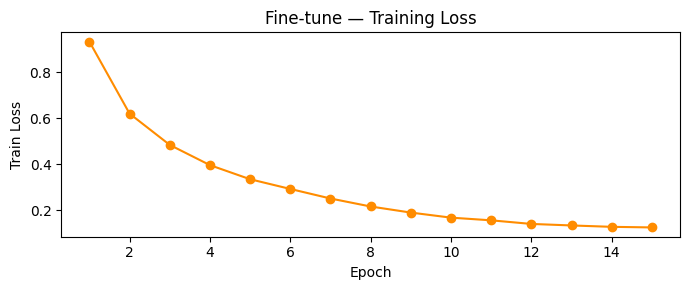

Saved loss curve.


In [18]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(finetune_train_losses) + 1), finetune_train_losses, marker="o", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Fine-tune — Training Loss")
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/unet_finetune_loss.png", dpi=120)
plt.show()
print("Saved loss curve.")

---
# PART C — Evaluation
Load *best* checkpoint (not last epoch) before every metric calculation.

## C0. Post-Processing: Connected Components → Bounding Boxes → Labels

In [ ]:
def masks_to_instances(pred_mask, num_classes, min_area=500):
    instances = []

    for c in range(1, num_classes):
        binary = (pred_mask == c).astype(np.uint8)
        if binary.sum() == 0:
            continue

        labeled, n_comp = ndi.label(binary)

        for i in range(1, n_comp + 1):
            comp_mask = (labeled == i)

            if comp_mask.sum() < min_area:
                continue

            rows = np.any(comp_mask, axis=1)
            cols = np.any(comp_mask, axis=0)

            y1, y2 = np.where(rows)[0][[0, -1]]
            x1, x2 = np.where(cols)[0][[0, -1]]

            bbox_area = max((x2 - x1) * (y2 - y1), 1)
            score = float(comp_mask[y1:y2+1, x1:x2+1].sum() / bbox_area)

            instances.append({
                "label": c,
                "bbox": [int(x1), int(y1), int(x2), int(y2)],
                "score": score,
                "mask": comp_mask,
            })

    return instances

## C1. Per-Class mIoU & Dice

In [ ]:
def evaluate_segmentation(model, loader, num_classes, device, split_name,
                           label_to_name, max_images=500):

    model.eval()

    intersection = np.zeros(num_classes)
    union        = np.zeros(num_classes)
    dice_num     = np.zeros(num_classes)
    dice_den     = np.zeros(num_classes)

    seen = 0

    with torch.no_grad():
        for imgs, masks in loader:
            if seen >= max_images:
                break

            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1)

            if TPU_AVAILABLE:
                xm.mark_step()

            preds = preds.cpu().numpy()
            masks = masks.numpy()

            for c in range(num_classes):
                p = (preds == c)
                g = (masks == c)

                intersection[c] += (p & g).sum()
                union[c]        += (p | g).sum()
                dice_num[c]     += 2 * (p & g).sum()
                dice_den[c]     += p.sum() + g.sum()

            seen += imgs.shape[0]

    print(f"\n{'='*55}")
    print(f" {split_name} — Per-Class Segmentation Metrics")
    print(f"{'='*55}")
    print(f"{'Class':<26} {'IoU':>8} {'Dice':>8}")
    print("-" * 45)

    ious, dices = [], []

    for c in range(1, num_classes):
        iou  = intersection[c] / (union[c] + 1e-6)
        dice = dice_num[c] / (dice_den[c] + 1e-6)

        name = label_to_name.get(c, f"class_{c}")

        print(f"{name:<26} {iou:>8.4f} {dice:>8.4f}")

        ious.append(iou)
        dices.append(dice)

    print("-" * 45)
    print(f"{'Macro Avg':<26} {np.mean(ious):>8.4f} {np.mean(dices):>8.4f}")

    return np.array(ious), np.array(dices)


# -------------------- Load checkpoints --------------------
def load_xla_safe(model, path):
    state_dict = torch.load(path, map_location="cpu", weights_only=False)

    model.load_state_dict(state_dict)
    model.to(DEVICE)

    if TPU_AVAILABLE:
        xm.mark_step()

    return model


print("Loading saved checkpoints...")


def _load_best(model, path):
    sd = torch.load(path, map_location="cpu", weights_only=False)

    if isinstance(sd, dict) and "model" in sd:
        sd = sd["model"]

    model.load_state_dict(sd)
    model.to(DEVICE)

    if TPU_AVAILABLE:
        xm.mark_step()


_load_best(model_scratch, SCRATCH_BEST_PATH)
_load_best(model_ft,      FINETUNE_BEST_PATH)


print("Checkpoints loaded successfully.")
print("Best checkpoints loaded.")
print("Running segmentation evaluation (capped at 500 images)…")


scratch_ious, scratch_dices = evaluate_segmentation(
    model_scratch,
    scratch_test_loader,
    NUM_CLASSES,
    DEVICE,
    "Scratch — Test",
    label_to_name
)

finetune_ious, finetune_dices = evaluate_segmentation(
    model_ft,
    finetune_test_loader,
    NUM_CLASSES,
    DEVICE,
    "Fine-tune — Test",
    label_to_name
)

Loading saved checkpoints...


Checkpoints loaded successfully.
Best checkpoints loaded.
Running segmentation evaluation (capped at 500 images)…


/tmp/ipykernel_74/440681767.py:83: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_74/440681767.py:23: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()              # flush XLA graph to prevent OOM on v5e



 Scratch — Test — Per-Class Segmentation Metrics
Class                           IoU     Dice
---------------------------------------------
short_sleeve_top             0.4820   0.6505
trousers                     0.5952   0.7462
shorts                       0.5427   0.7036
long_sleeve_top              0.3626   0.5322
skirt                        0.4006   0.5721
---------------------------------------------
Macro Avg                    0.4766   0.6409



 Fine-tune — Test — Per-Class Segmentation Metrics
Class                           IoU     Dice
---------------------------------------------
short_sleeve_top             0.6849   0.8130
trousers                     0.6774   0.8077
shorts                       0.6383   0.7793
long_sleeve_top              0.5826   0.7363
skirt                        0.6013   0.7510
---------------------------------------------
Macro Avg                    0.6369   0.7774


## C2. COCO-style mAP (bbox)

In [ ]:
def compute_iou_bbox(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)


def coco_map(model, records, cat_to_label, img_size, device,
             num_classes, iou_thresholds=None, max_images=500):

    if iou_thresholds is None:
        iou_thresholds = [round(t, 2) for t in np.arange(0.50, 1.00, 0.05)]

    all_preds = {c: [] for c in range(1, num_classes)}
    all_gt_counts = {c: 0 for c in range(1, num_classes)}

    model.eval()
    tfm = get_val_transforms()

    for rec in records[:max_images]:
        img_pil = Image.open(rec["image_path"]).convert("RGB")
        orig_w, orig_h = img_pil.size

        img_pil = img_pil.resize((img_size, img_size), Image.BILINEAR)
        img_t = tfm(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_mask = model(img_t).argmax(dim=1)[0].cpu().numpy()

        sx = orig_w / img_size
        sy = orig_h / img_size

        pred_insts = masks_to_instances(pred_mask, num_classes)

        gt_boxes = {c: [] for c in range(1, num_classes)}
        for item in rec["items"]:
            c = cat_to_label.get(item["category_id"])
            if c is None:
                continue

            x1, y1, x2, y2 = item["bbox"]
            gt_boxes[c].append([x1, y1, x2, y2])
            all_gt_counts[c] += 1

        for inst in pred_insts:
            c = inst["label"]

            bx1, by1, bx2, by2 = inst["bbox"]
            pred_box = [bx1 * sx, by1 * sy, bx2 * sx, by2 * sy]

            best_iou = 0.0
            for gb in gt_boxes.get(c, []):
                best_iou = max(best_iou, compute_iou_bbox(pred_box, gb))

            all_preds[c].append((inst["score"], best_iou))

    all_aps = []

    for iou_thr in iou_thresholds:
        class_aps = []

        for c in range(1, num_classes):
            n_gt = all_gt_counts[c]
            if n_gt == 0:
                continue

            preds_c = sorted(all_preds[c], key=lambda x: -x[0])

            tp_cumsum = 0
            prec, rec = [], []

            for rank, (score, iou_val) in enumerate(preds_c, 1):
                if iou_val >= iou_thr:
                    tp_cumsum += 1

                prec.append(tp_cumsum / rank)
                rec.append(tp_cumsum / n_gt)

            ap = np.trapezoid(prec, rec) if len(prec) > 1 else 0.0
            class_aps.append(ap)

        all_aps.append(np.mean(class_aps) if class_aps else 0.0)

    return float(np.mean(all_aps)), float(all_aps[0])


print("Computing COCO-style mAP (this may take a few minutes)…")

scratch_map, scratch_map50 = coco_map(
    model_scratch,
    scratch_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    NUM_CLASSES
)

finetune_map, finetune_map50 = coco_map(
    model_ft,
    finetune_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    NUM_CLASSES
)

print(f"\nScratch  — mAP@.50={scratch_map50:.4f}  mAP@[.5:.95]={scratch_map:.4f}")
print(f"Fine-tune — mAP@.50={finetune_map50:.4f}  mAP@[.5:.95]={finetune_map:.4f}")

Computing COCO-style mAP (this may take a few minutes)…



Scratch  — mAP@.50=0.5039  mAP@[.5:.95]=0.2634
Fine-tune — mAP@.50=0.6731  mAP@[.5:.95]=0.3978


## C3. ROC / AUC


Scratch — Test — Per-Class AUC:
  short_sleeve_top          : 0.8463
  trousers                  : 0.9620
  shorts                    : 0.9459
  long_sleeve_top           : 0.8834
  skirt                     : 0.8750
  Macro AUC                 : 0.9025


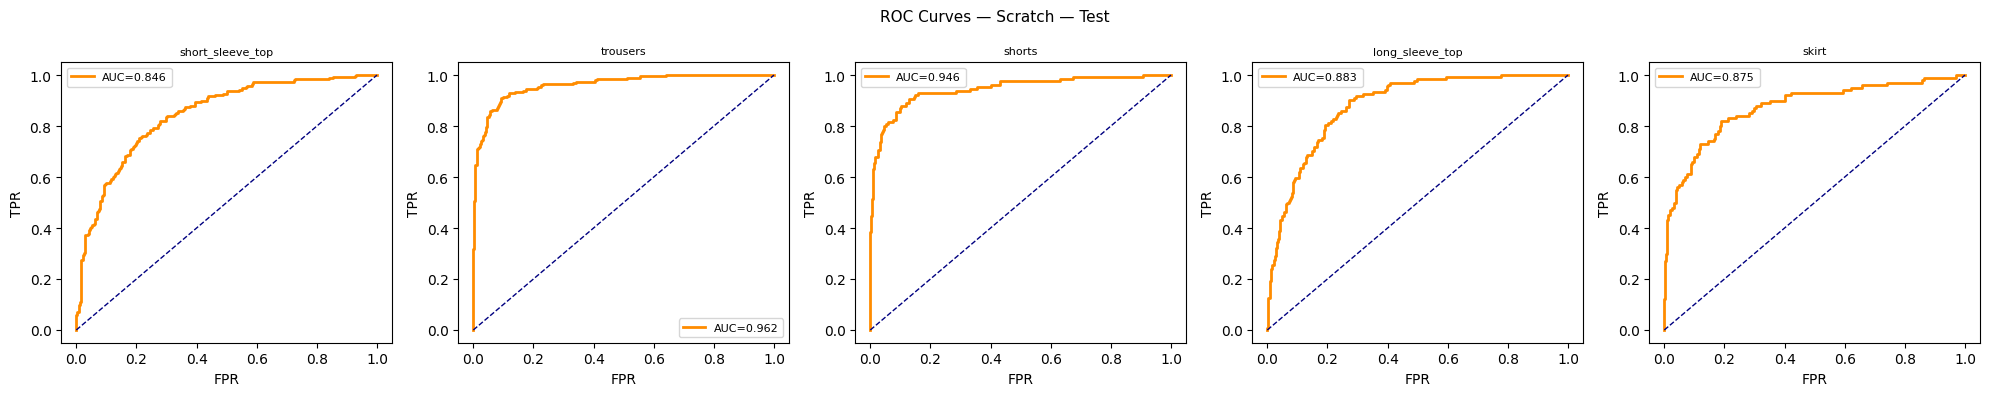

  Saved: /kaggle/working/roc_scratch__test.png



Fine-tune — Test — Per-Class AUC:
  short_sleeve_top          : 0.9284
  trousers                  : 0.9785
  shorts                    : 0.9700
  long_sleeve_top           : 0.9339
  skirt                     : 0.9341
  Macro AUC                 : 0.9490


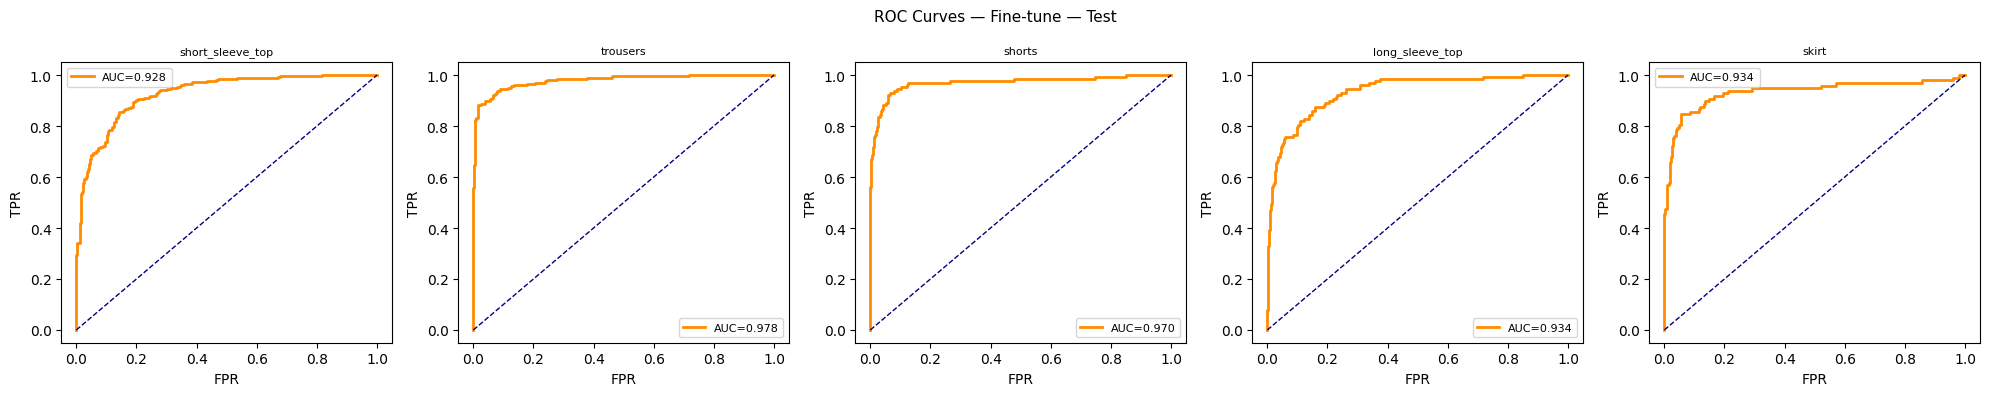

  Saved: /kaggle/working/roc_fine-tune__test.png


In [ ]:
def compute_roc_auc(model, records, cat_to_label, img_size, device,
                    num_classes, label_to_name, split_name, max_images=500):

    model.eval()
    tfm = get_val_transforms()

    y_true   = {c: [] for c in range(1, num_classes)}
    y_scores = {c: [] for c in range(1, num_classes)}

    for rec in records[:max_images]:
        img_t = tfm(
            Image.open(rec["image_path"])
            .convert("RGB")
            .resize((img_size, img_size), Image.BILINEAR)
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            probs = torch.softmax(model(img_t), dim=1)[0].cpu().numpy()

        present = {
            cat_to_label[it["category_id"]]
            for it in rec["items"]
            if it["category_id"] in cat_to_label
        }

        for c in range(1, num_classes):
            y_true[c].append(1 if c in present else 0)
            y_scores[c].append(float(probs[c].max()))

    nc = num_classes - 1

    fig, axes = plt.subplots(1, nc, figsize=(4 * nc, 4))
    if nc == 1:
        axes = [axes]

    print(f"\n{split_name} — Per-Class AUC:")

    aucs = []

    for i, c in enumerate(range(1, num_classes)):
        if sum(y_true[c]) == 0:
            print(f"  {label_to_name.get(c,'cls'+str(c)):<26}: N/A (no positives)")
            axes[i].text(0.5, 0.5, "No positives", ha="center", va="center")
        else:
            fpr, tpr, _ = roc_curve(y_true[c], y_scores[c])
            roc_auc = auc(fpr, tpr)

            aucs.append(roc_auc)

            name = label_to_name.get(c, f"cls_{c}")

            print(f"  {name:<26}: {roc_auc:.4f}")

            axes[i].plot(fpr, tpr, lw=2, label=f"AUC={roc_auc:.3f}")
            axes[i].plot([0, 1], [0, 1], "--", lw=1)

            axes[i].set_title(name, fontsize=8)
            axes[i].set_xlabel("FPR")
            axes[i].set_ylabel("TPR")
            axes[i].legend(fontsize=8)

    if aucs:
        print(f"  {'Macro AUC':<26}: {np.mean(aucs):.4f}")

    plt.suptitle(f"ROC Curves — {split_name}", fontsize=11)
    plt.tight_layout()

    fname = f"{WORK_DIR}/roc_{split_name.lower().replace(' ','_').replace('—','')}.png"
    plt.savefig(fname, dpi=120)

    plt.show()

    print(f"  Saved: {fname}")


compute_roc_auc(
    model_scratch,
    scratch_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    NUM_CLASSES,
    label_to_name,
    "Scratch — Test"
)

compute_roc_auc(
    model_ft,
    finetune_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    NUM_CLASSES,
    label_to_name,
    "Fine-tune — Test"
)

## C4. Per-Class F1 / Precision / Recall

In [ ]:
def evaluate_per_class_f1(model, records, cat_to_label, img_size, device,
                           num_classes, label_to_name, split_name,
                           iou_thr=0.5, max_images=500):

    model.eval()
    tfm = get_val_transforms()

    tp = {c: 0 for c in range(1, num_classes)}
    fp = {c: 0 for c in range(1, num_classes)}
    fn = {c: 0 for c in range(1, num_classes)}

    for rec in records[:max_images]:
        img = Image.open(rec["image_path"]).convert("RGB")
        orig_w, orig_h = img.size

        img_t = tfm(img.resize((img_size, img_size), Image.BILINEAR)).unsqueeze(0).to(device)

        sx = orig_w / img_size
        sy = orig_h / img_size

        with torch.no_grad():
            pred_mask = model(img_t).argmax(dim=1)[0].cpu().numpy()

        pred_insts = masks_to_instances(pred_mask, num_classes)

        gt_boxes = {c: [] for c in range(1, num_classes)}

        for item in rec["items"]:
            c = cat_to_label.get(item["category_id"])
            if c:
                gt_boxes[c].append(item["bbox"])
                fn[c] += 1

        matched_gt = {c: set() for c in range(1, num_classes)}

        for inst in pred_insts:
            c = inst["label"]

            bx1, by1, bx2, by2 = inst["bbox"]
            pred_box = [bx1 * sx, by1 * sy, bx2 * sx, by2 * sy]

            best_iou, best_j = 0.0, -1

            for j, gb in enumerate(gt_boxes.get(c, [])):
                iou = compute_iou_bbox(pred_box, gb)
                if iou > best_iou:
                    best_iou, best_j = iou, j

            if best_iou >= iou_thr and best_j not in matched_gt[c]:
                tp[c] += 1
                fn[c] -= 1
                matched_gt[c].add(best_j)
            else:
                fp[c] += 1

    print(f"\n{'='*60}")
    print(f" {split_name} — Per-Class F1 @ IoU={iou_thr}")
    print(f"{'='*60}")
    print(f"{'Class':<26} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print("-" * 56)

    precs, recs, f1s = [], [], []

    for c in range(1, num_classes):
        prec = tp[c] / (tp[c] + fp[c] + 1e-6)
        rec  = tp[c] / (tp[c] + fn[c] + 1e-6)
        f1   = 2 * prec * rec / (prec + rec + 1e-6)

        name = label_to_name.get(c, f"cls_{c}")

        print(f"{name:<26} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)

    print("-" * 56)
    print(f"{'Macro Avg':<26} {np.mean(precs):>10.4f} "
          f"{np.mean(recs):>8.4f} {np.mean(f1s):>8.4f}")

    return np.mean(f1s)


scratch_f1 = evaluate_per_class_f1(
    model_scratch,
    scratch_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    NUM_CLASSES,
    label_to_name,
    "Scratch — Test"
)

finetune_f1 = evaluate_per_class_f1(
    model_ft,
    finetune_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    NUM_CLASSES,
    label_to_name,
    "Fine-tune — Test"
)


 Scratch — Test — Per-Class F1 @ IoU=0.5
Class                       Precision   Recall       F1
--------------------------------------------------------
short_sleeve_top               0.4461   0.7459   0.5583
trousers                       0.6059   0.8232   0.6981
shorts                         0.5747   0.7576   0.6536
long_sleeve_top                0.2822   0.8444   0.4230
skirt                          0.3106   0.7228   0.4345
--------------------------------------------------------
Macro Avg                      0.4439   0.7788   0.5535



 Fine-tune — Test — Per-Class F1 @ IoU=0.5
Class                       Precision   Recall       F1
--------------------------------------------------------
short_sleeve_top               0.6974   0.8689   0.7737
trousers                       0.7811   0.8966   0.8349
shorts                         0.7953   0.7953   0.7953
long_sleeve_top                0.6133   0.7187   0.6619
skirt                          0.7080   0.8247   0.7619
--------------------------------------------------------
Macro Avg                      0.7190   0.8208   0.7655


## C5. Qualitative Visualisation

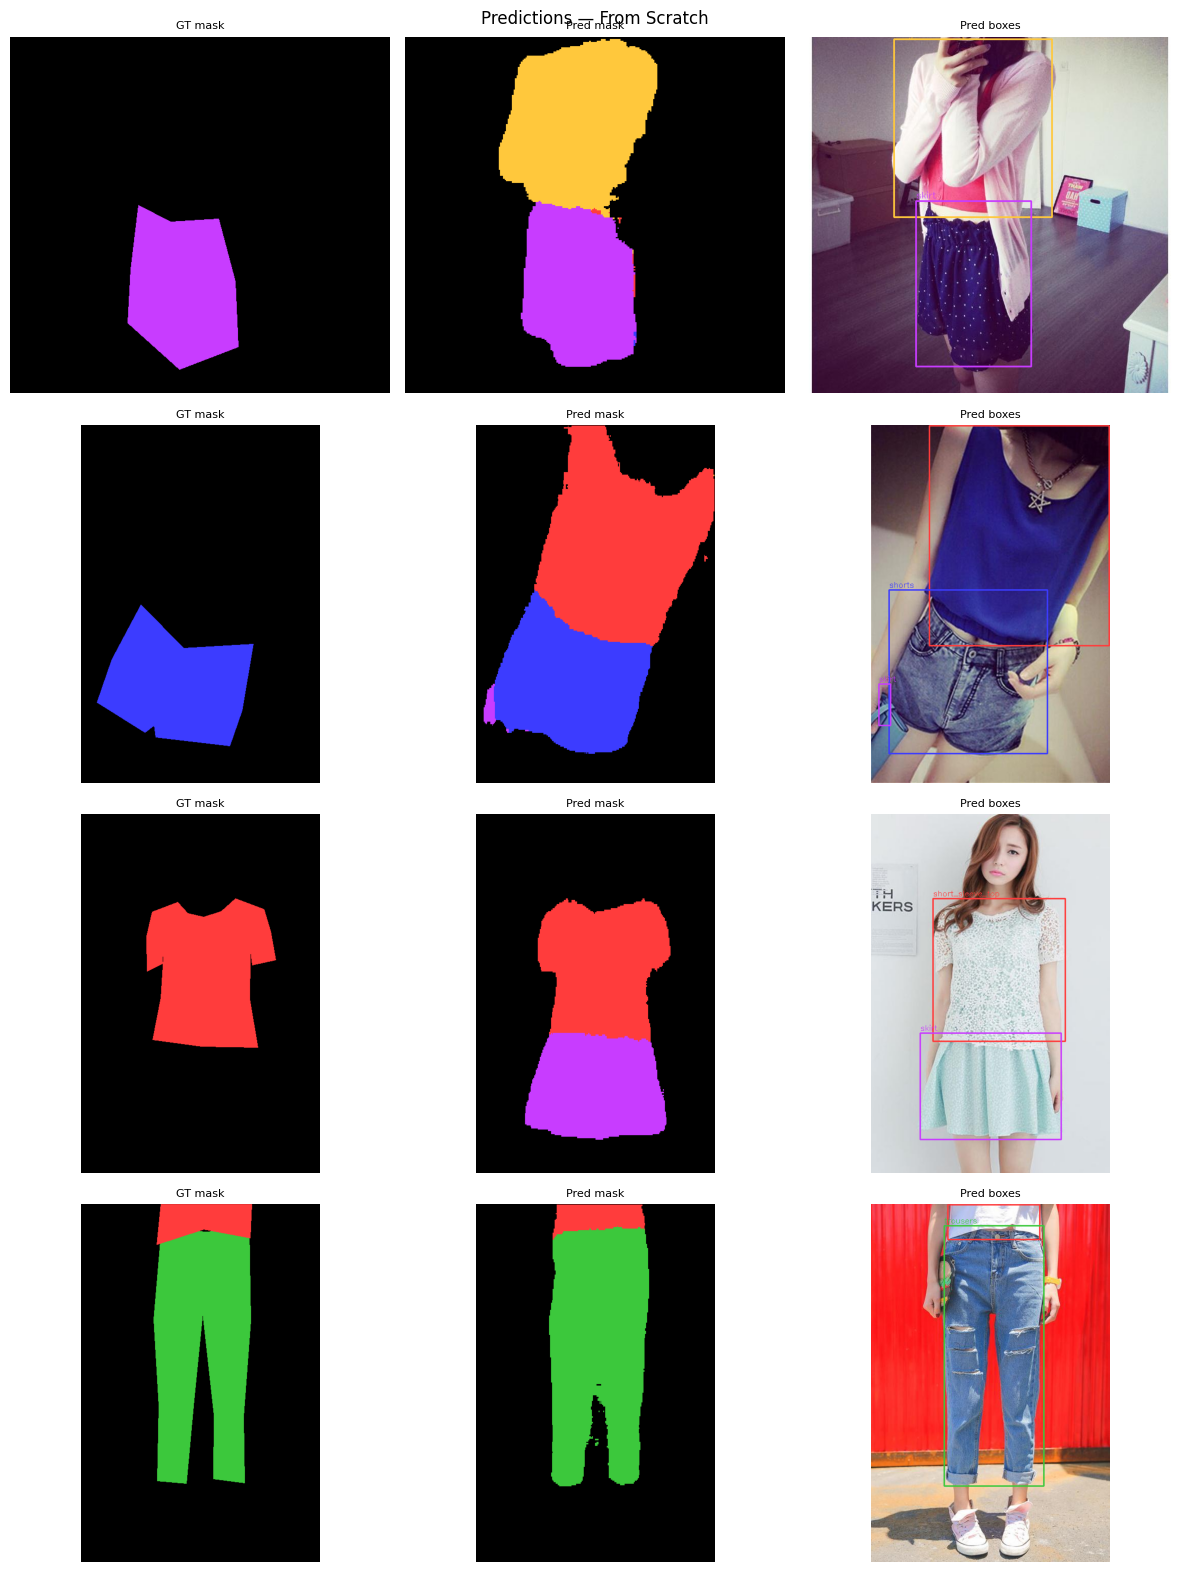

Saved: /kaggle/working/viz_from_scratch.png


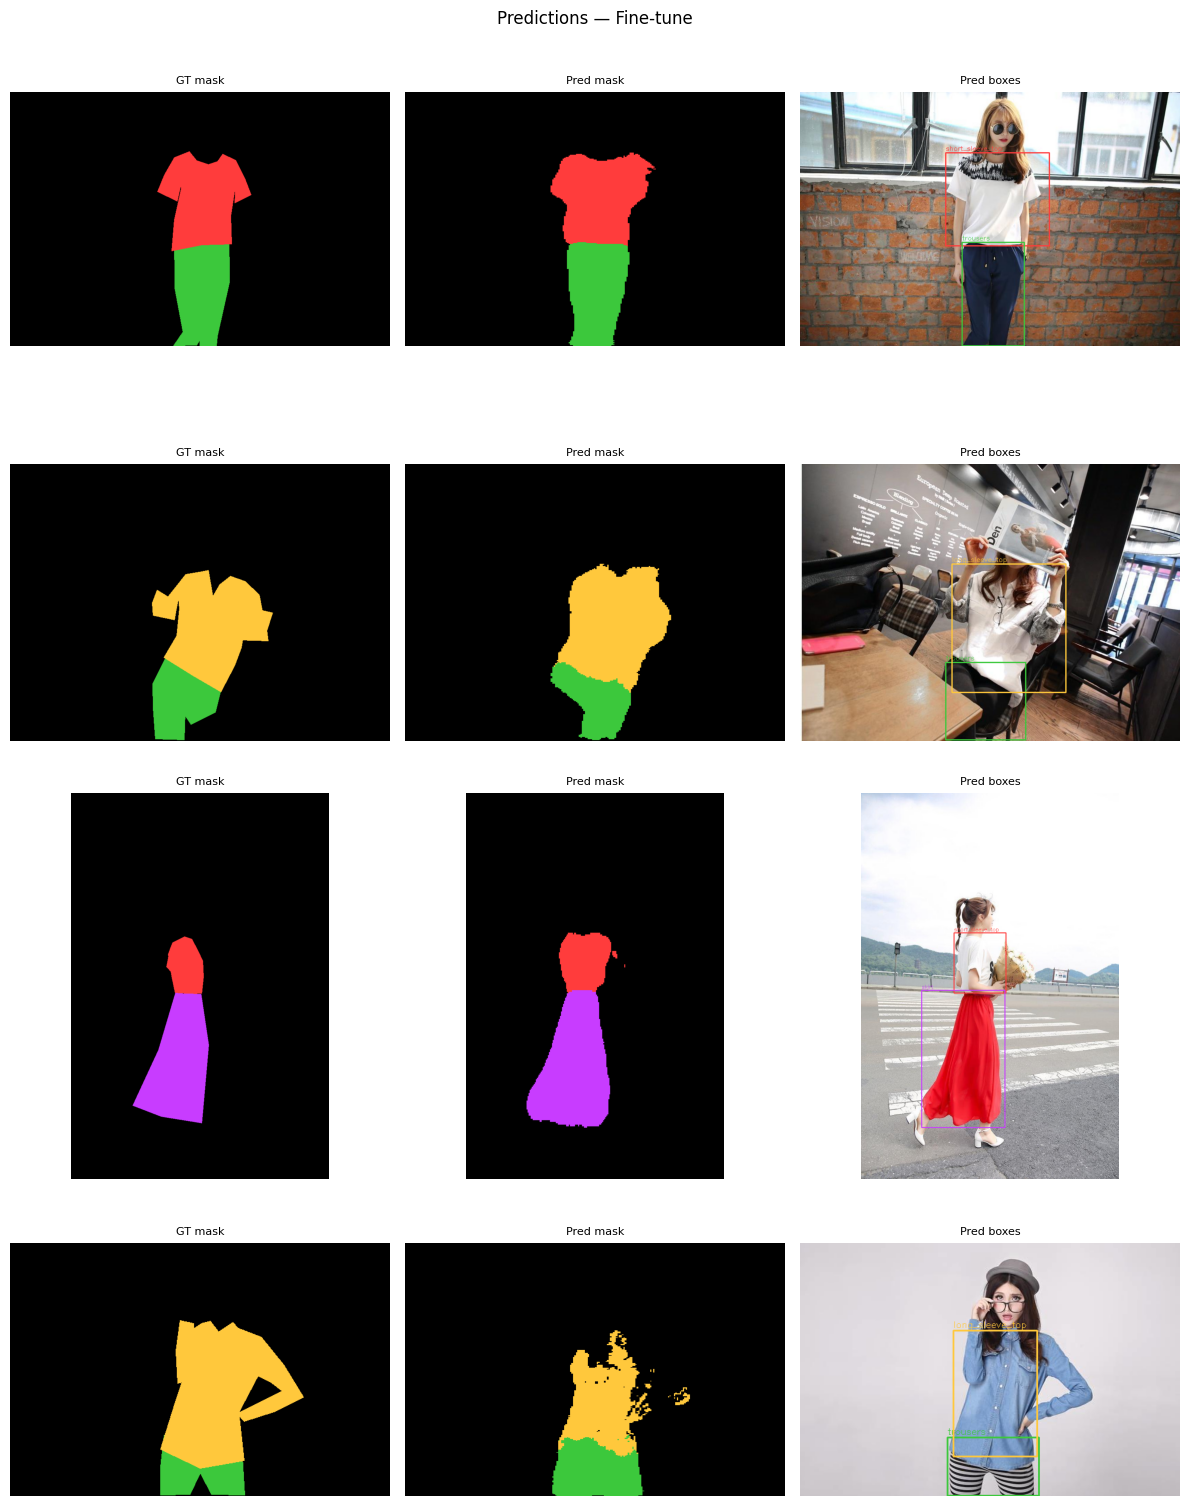

Saved: /kaggle/working/viz_fine-tune.png


In [ ]:
# Colour palette for masks
PALETTE = np.array([
    [0,   0,   0],
    [255, 60,  60],
    [60,  200, 60],
    [60,  60,  255],
    [255, 200, 60],
    [200, 60,  255],
], dtype=np.uint8)


def visualise_predictions(model, records, cat_to_label, img_size, device,
                           label_to_name, model_name, n=4):

    model.eval()
    samples = random.sample(records, min(n, len(records)))
    tfm = get_val_transforms()

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.array(axes).reshape(n, 3)

    for row, rec in enumerate(samples):
        img_pil = Image.open(rec["image_path"]).convert("RGB")
        orig_w, orig_h = img_pil.size

        img_resized = img_pil.resize((img_size, img_size), Image.BILINEAR)
        img_t = tfm(img_resized).unsqueeze(0).to(device)

        gt_mask = build_semantic_mask(rec, orig_w, orig_h, cat_to_label)

        with torch.no_grad():
            pred_mask = model(img_t).argmax(dim=1)[0].cpu().numpy()

        pred_mask_orig = cv2.resize(
            pred_mask.astype(np.uint8),
            (orig_w, orig_h),
            interpolation=cv2.INTER_NEAREST
        )

        gt_rgb = PALETTE[np.clip(gt_mask, 0, len(PALETTE)-1)]
        pred_rgb = PALETTE[np.clip(pred_mask_orig, 0, len(PALETTE)-1)]

        img_np = np.array(img_pil)

        for inst in masks_to_instances(pred_mask_orig, NUM_CLASSES):
            x1, y1, x2, y2 = inst["bbox"]
            clr = [int(c) for c in PALETTE[inst["label"]]]

            cv2.rectangle(img_np, (x1, y1), (x2, y2), clr, 2)
            cv2.putText(
                img_np,
                label_to_name.get(inst["label"], ""),
                (x1, max(y1 - 5, 0)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                clr,
                1
            )

        axes[row, 0].imshow(gt_rgb)
        axes[row, 0].set_title("GT mask", fontsize=8)

        axes[row, 1].imshow(pred_rgb)
        axes[row, 1].set_title("Pred mask", fontsize=8)

        axes[row, 2].imshow(img_np)
        axes[row, 2].set_title("Pred boxes", fontsize=8)

        for ax in axes[row]:
            ax.axis("off")

    plt.suptitle(f"Predictions — {model_name}", fontsize=12)
    plt.tight_layout()

    fname = f"{WORK_DIR}/viz_{model_name.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=120)

    plt.show()

    print(f"Saved: {fname}")


visualise_predictions(
    model_scratch,
    scratch_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    label_to_name,
    "From Scratch"
)

visualise_predictions(
    model_ft,
    finetune_test,
    cat_to_label,
    IMG_SIZE,
    DEVICE,
    label_to_name,
    "Fine-tune"
)

## C6. Comparison Table

In [ ]:
rows = {
    "Metric": [
        "Macro mIoU",
        "Macro Dice",
        "mAP@0.5  (bbox)",
        "mAP@[.5:.95] (bbox)",
        "Macro F1 @ IoU=0.5",
    ],
    "From Scratch": [
        f"{np.mean(scratch_ious):.4f}",
        f"{np.mean(scratch_dices):.4f}",
        f"{scratch_map50:.4f}",
        f"{scratch_map:.4f}",
        f"{scratch_f1:.4f}",
    ],
    "Fine-tune": [
        f"{np.mean(finetune_ious):.4f}",
        f"{np.mean(finetune_dices):.4f}",
        f"{finetune_map50:.4f}",
        f"{finetune_map:.4f}",
        f"{finetune_f1:.4f}",
    ],
}

df_cmp = pd.DataFrame(rows)

print("\nU-Net Comparison Table — Test Set")
print(df_cmp.to_string(index=False))


df_cmp.to_csv(f"{WORK_DIR}/unet_comparison.csv", index=False)

print(f"\nSaved: {WORK_DIR}/unet_comparison.csv")


U-Net Comparison Table — Test Set
             Metric From Scratch Fine-tune
         Macro mIoU       0.4766    0.6369
         Macro Dice       0.6409    0.7774
    mAP@0.5  (bbox)       0.5039    0.6731
mAP@[.5:.95] (bbox)       0.2634    0.3978
 Macro F1 @ IoU=0.5       0.5535    0.7655

Saved: /kaggle/working/unet_comparison.csv
